# Phase 4 — Inferential Statistics

**Primary business question (Section 1):** *What are the top drivers of low review scores (≤ 3) on Olist, and which interventions would produce the largest lift in average review score?*

This notebook runs five hypothesis tests, each tied to a sub-question. For every test: **H₀ / H₁ → a one-line assumption note → the test statistic + p-value → a plain-English business conclusion.** The predictive model and prescriptive simulation live in `05_modeling.ipynb`.

| Test | Sub-question |
|---|---|
| Welch's t-test | #2 — Do low-review orders have longer delivery gaps? |
| One-way ANOVA + Tukey HSD | #3 — Do review scores differ across the top-6 categories? |
| Levene's test | #4 — Is delivery-gap *variance* worse in the worst states? |
| Chi-square | #5 — Are high installment counts linked to low reviews? |
| Spearman correlation | Is freight-to-price ratio related to review score? |

## Setup

Reads `orders_clean.parquet`, drops the 646 orders with no review (target undefined), and derives the two helper columns the tests need.

In [1]:
import os, sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if Path.cwd().name == "notebooks":
    os.chdir("..")
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
ALPHA = 0.05


def verdict(p):
    return f"p = {p:.3g}  ->  {'REJECT H0' if p < ALPHA else 'fail to reject H0'} at α = {ALPHA}"


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"saved -> reports/figures/{name}.png")

In [2]:
orders = duckdb.sql("SELECT * FROM 'data/processed/orders_clean.parquet'").df().dropna(subset=["review_score"])
orders = orders.copy()
orders["freight_ratio"] = orders["total_freight"] / orders["total_price"].replace(0, np.nan)
orders["low_review"] = (orders["review_score"] <= 3).astype(int)

low = orders[orders["review_score"] <= 3]
high = orders[orders["review_score"] >= 4]
print(f"reviewed orders: {len(orders):,}   low (≤3): {len(low):,}   high (≥4): {len(high):,}")

reviewed orders: 95,824   low (≤3): 20,188   high (≥4): 75,636


## Test 1 — Welch's two-sample t-test (sub-question #2)

**Question:** Do orders with review ≤ 3 have a significantly *longer* delivery gap than orders with review ≥ 4?

- **H₀:** mean delivery gap is equal for low- and high-review orders.
- **H₁:** low-review orders have a larger (more positive) mean delivery gap.

**Assumption note:** Welch's t-test does not assume equal variances. With ~20k and ~76k orders per group the Central Limit Theorem makes the test of *means* robust to the non-normal gap distribution, so a QQ-plot visual check is sufficient (Shapiro–Wilk is uninformative at this n — it rejects on trivial deviations). One-sided test.

saved -> reports/figures/t1_qq_delivery_gap.png


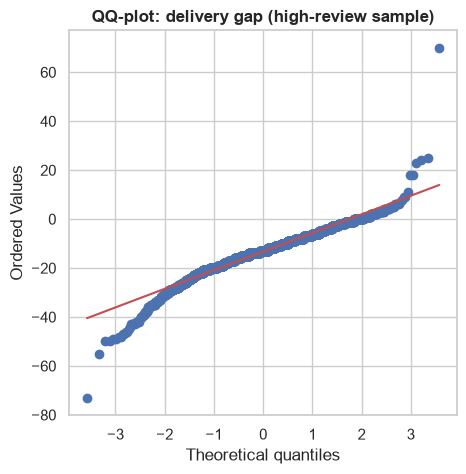

mean gap  low (≤3): -7.34 days
mean gap  high (≥4): -13.13 days
difference: 5.80 days
t = 56.41   p = 0  ->  REJECT H0 at α = 0.05 (one-sided)


In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(high["delivery_gap_days"].sample(4000, random_state=1), plot=ax)
ax.set_title("QQ-plot: delivery gap (high-review sample)")
save_fig(fig, "t1_qq_delivery_gap")
plt.show()

t_stat, p_two = stats.ttest_ind(low["delivery_gap_days"], high["delivery_gap_days"], equal_var=False)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
print(f"mean gap  low (≤3): {low['delivery_gap_days'].mean():.2f} days")
print(f"mean gap  high (≥4): {high['delivery_gap_days'].mean():.2f} days")
print(f"difference: {low['delivery_gap_days'].mean() - high['delivery_gap_days'].mean():.2f} days")
print(f"t = {t_stat:.2f}   {verdict(p_one)} (one-sided)")

**Conclusion.** Low-review orders average a delivery gap of **−7.3 days** vs **−13.1 days** for high-review orders — a **5.8-day** smaller early-delivery cushion (t = 56.4, p ≈ 0). Late/less-early delivery is significantly associated with low reviews, confirming delivery as a primary lever.

## Test 2 — One-way ANOVA + Tukey HSD (sub-question #3)

**Question:** Do average review scores differ significantly across the top-6 categories by volume? If so, which pairs differ?

- **H₀:** all six categories share the same mean review score.
- **H₁:** at least one category's mean differs.

**Assumption note:** ANOVA assumes independent groups and roughly comparable spread; with thousands of orders per category it is robust to the discrete 1–5 scale. Tukey HSD then controls the family-wise error rate across all pairwise comparisons.

In [4]:
top6 = orders["primary_category"].value_counts().head(6).index.tolist()
sub = orders[orders["primary_category"].isin(top6)]
groups = [sub.loc[sub["primary_category"] == c, "review_score"] for c in top6]

F_stat, p_anova = stats.f_oneway(*groups)
print("top-6 categories:", top6)
print(sub.groupby("primary_category")["review_score"].mean().sort_values().round(3).to_string())
print(f"\nANOVA  F = {F_stat:.2f}   {verdict(p_anova)}")

tukey = pairwise_tukeyhsd(sub["review_score"], sub["primary_category"], alpha=ALPHA)
print("\nTukey HSD (reject = the two categories differ significantly):")
print(tukey.summary())

top-6 categories: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'housewares']
primary_category
bed_bath_table          4.0080
furniture_decor         4.0790
computers_accessories   4.0830
housewares              4.2040
health_beauty           4.2330
sports_leisure          4.2350

ANOVA  F = 43.52   p = 6.37e-45  ->  REJECT H0 at α = 0.05



Tukey HSD (reject = the two categories differ significantly):
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
       bed_bath_table computers_accessories    0.075  0.005  0.0149 0.1351   True
       bed_bath_table       furniture_decor   0.0706 0.0126  0.0096 0.1316   True
       bed_bath_table         health_beauty   0.2246    0.0   0.169 0.2803   True
       bed_bath_table            housewares   0.1957    0.0   0.133 0.2583   True
       bed_bath_table        sports_leisure   0.2269    0.0  0.1692 0.2847   True
computers_accessories       furniture_decor  -0.0044    1.0 -0.0702 0.0614  False
computers_accessories         health_beauty   0.1496    0.0  0.0888 0.2104   True
computers_accessories            housewares   0.1207    0.0  0.0534 0.1879   True
computers_accessories        sports

**Conclusion.** Category means span **4.01 (bed_bath_table) to 4.24 (sports_leisure)** and the difference is significant (F = 43.5, p ≈ 6e−45). Tukey shows `bed_bath_table` and `computers_accessories` sit significantly below the healthier categories — review quality is not uniform, so category is a real prioritisation axis, not noise.

## Test 3 — Levene's test (sub-question #4)

**Question:** Is delivery-gap *variance* different between the 5 best- and 5 worst-reviewed states? (Unequal variance means inconsistent delivery, a different problem than a low average.)

- **H₀:** delivery-gap variance is equal in the two state groups.
- **H₁:** the variances differ.

**Assumption note:** Levene's test is the standard variance-equality check and is robust to non-normality (it works on absolute deviations from the group centre). To avoid noise from tiny states, best/worst are chosen among states with **≥ 500 orders**.

In [5]:
st = orders.groupby("customer_state").agg(n=("review_score", "size"), avg=("review_score", "mean"))
st = st[st["n"] >= 500].sort_values("avg")
worst5, best5 = st.head(5).index.tolist(), st.tail(5).index.tolist()

gap_worst = orders.loc[orders["customer_state"].isin(worst5), "delivery_gap_days"]
gap_best = orders.loc[orders["customer_state"].isin(best5), "delivery_gap_days"]
W_stat, p_lev = stats.levene(gap_worst, gap_best)

print(f"worst-5 review states: {worst5}   gap variance = {gap_worst.var():.1f}")
print(f"best-5  review states: {best5}   gap variance = {gap_best.var():.1f}")
print(f"\nLevene  W = {W_stat:.2f}   {verdict(p_lev)}")

worst-5 review states: ['MA', 'PA', 'BA', 'CE', 'RJ']   gap variance = 179.8
best-5  review states: ['MS', 'RS', 'MG', 'PR', 'SP']   gap variance = 73.8

Levene  W = 2527.20   p = 0  ->  REJECT H0 at α = 0.05


**Conclusion.** Delivery-gap variance in the worst-reviewed states (**179.8**) is roughly **2.4×** that of the best states (**73.8**), and the difference is significant (W = 2527, p ≈ 0). The worst states don't just deliver later on average — their delivery is far more *inconsistent*, so the fix there is reliability, not only speed.

## Test 4 — Chi-square test of independence (sub-question #5)

**Question:** Is a high installment count (> 6) associated with a higher rate of low reviews?

- **H₀:** low-review rate is independent of whether the order used > 6 installments.
- **H₁:** the two are associated.

**Assumption note:** Chi-square needs expected cell counts ≥ 5 — easily met here (both groups have thousands of orders). It tests association, not direction or size, so we read the raw rates alongside it.

In [6]:
orders["high_installments"] = orders["max_installments"] > 6
ct = pd.crosstab(orders["high_installments"], orders["low_review"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)

print(ct.rename(columns={0: "high_review", 1: "low_review"},
                index={False: "installments<=6", True: "installments>6"}).to_string())
print(f"\nlow-review rate  >6 installments: {orders.loc[orders['high_installments'], 'low_review'].mean():.3f}")
print(f"low-review rate <=6 installments: {orders.loc[~orders['high_installments'], 'low_review'].mean():.3f}")
print(f"\nchi2 = {chi2:.2f}  dof = {dof}   {verdict(p_chi)}")

low_review         high_review  low_review
high_installments                         
installments<=6          66717       17445
installments>6            8919        2743

low-review rate  >6 installments: 0.235
low-review rate <=6 installments: 0.207

chi2 = 47.88  dof = 1   p = 4.53e-12  ->  REJECT H0 at α = 0.05


**Conclusion.** Orders with > 6 installments are low-reviewed **23.5%** of the time vs **20.7%** otherwise — a statistically significant association (χ² = 47.9, p ≈ 5e−12) but a **small** one (~3 points). Installment burden nudges dissatisfaction upward but is a secondary factor, not a headline driver.

## Test 5 — Spearman correlation

**Question:** Is the freight-to-price ratio correlated with review score?

- **H₀:** no monotonic association between freight ratio and review score (ρ = 0).
- **H₁:** a monotonic association exists (ρ ≠ 0).

**Assumption note:** Spearman (rank-based) is the right choice because review score is ordinal (1–5) and the freight ratio is heavily right-skewed — no normality or linearity assumed.

In [7]:
fr = orders.dropna(subset=["freight_ratio"])
rho, p_sp = stats.spearmanr(fr["freight_ratio"], fr["review_score"])
print(f"Spearman ρ = {rho:.3f}   {verdict(p_sp)}")

Spearman ρ = -0.031   p = 7.76e-22  ->  REJECT H0 at α = 0.05


**Conclusion.** There is a **significant but very weak negative** correlation (ρ = −0.03, p ≈ 8e−22): higher relative freight goes with slightly lower reviews, but the effect is tiny. Freight burden is real at the margin, not a lever that would move the marketplace average — consistent with the EDA boxplot.

## Inferential findings summary

1. **Delivery gap — significant, large.** Low-review orders lose ~5.8 days of early-delivery cushion vs high-review orders (Welch t = 56.4, p ≈ 0). Delivery is a primary driver.
2. **Category — significant.** Review means differ across the top-6 categories (ANOVA F = 43.5, p ≈ 6e−45); `bed_bath_table` and `computers_accessories` are significantly worse (Tukey). Category is a real prioritisation axis.
3. **State variance — significant, large.** Worst-reviewed states have ~2.4× the delivery-gap variance of the best (Levene W = 2527, p ≈ 0) — inconsistency, not just slowness.
4. **Installments — significant, small.** > 6 installments raises the low-review rate ~3 points (χ² = 47.9, p ≈ 5e−12). Secondary factor.
5. **Freight ratio — significant, negligible.** ρ = −0.03 (p ≈ 8e−22). Real but not a lever.

**Handoff to `05_modeling.ipynb`:** the significant drivers (delivery gap, category, state) should surface as top features; installments and freight ratio should rank low. SHAP will be checked against exactly this ordering.